# Precip statistics from SEA-POL when it is raining at the ship
- SEA-POL 2D low-level rain rate
- Rain gauge

(Also looked at disdrometer and it gave very similar results)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc, colors, ticker
from matplotlib.colors import ListedColormap
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pandas as pd
import cftime
import seaborn as sns
import json
import glob
import os
from scipy.stats import pearsonr
from scipy.stats import spearmanr

In [2]:
# define threshold for raining at ship (fraction of time precip was observed at ship during that 10-minute period)
pfreq_threshold = 0

In [3]:
# Define color-blind safe colors
cb_orange = [230/255, 159/255, 0]
cb_skyblue = [86/255, 180/255, 233/255]
cb_green = [0, 158/255, 115/255]
cb_yellow = [240/255, 228/255, 66/255]
cb_blue = [0, 114/255, 178/255]
cb_red = [213/255, 94/255, 0]
cb_purple = [204/255, 121/255, 167/255]


In [4]:
#Set start and end times
start_time = np.datetime64('2024-08-16T08:00:00')
end_time = np.datetime64('2024-09-23T16:50:00')

### DSHIP data

In [5]:
#Open ship data
#CID: QmSSrT1UdtocfQS5yWSHFEJwJjqcNXjq2F1QfvNgLuEqSN
DSHIP = xr.open_dataset('ipns://latest.orcestra-campaign.org/products/METEOR/DShip.zarr',engine='zarr')
#DSHIP = xr.open_dataset('../../data/meteor_meteo_dship_20240923.nc')
DSHIP

<xarray.Dataset> Size: 20MB
Dimensions:           (time: 58980)
Coordinates:
    lat               (time) float64 472kB ...
    lon               (time) float64 472kB ...
  * time              (time) datetime64[ns] 472kB 2024-08-14 ... 2024-09-23T2...
Data variables: (12/39)
    PM1               (time) float64 472kB ...
    PM10              (time) float64 472kB ...
    PM2p5             (time) float64 472kB ...
    lwr               (time) float64 472kB ...
    p_air             (time) float64 472kB ...
    rh_board          (time) float64 472kB ...
    ...                ...
    wdir              (time) float64 472kB ...
    wdir_rel          (time) float64 472kB ...
    wspd              (time) float64 472kB ...
    wspd_kn           (time) float64 472kB ...
    wspd_rel          (time) float64 472kB ...
    wspd_rel_kn       (time) float64 472kB ...
Attributes:
    creator_email:  hans.segura@mpimet.mpg.de
    creator_name:   Hans Segura
    featureType:    trajectory
    history:        Converted to Zarr by Lukas Kluft (lukas.kluft@mpimet.mpg.de)
    license:        CC-BY-4.0
    platform:       RV METEOR
    project:        ORCESTRA, BOW-TIE
    source:         DVS DShip
    title:          Ship information database (DVS DShip) of METEOR cruise M203

In [6]:
#Find indices for start and end times
index_start = np.where(pd.to_datetime(DSHIP.time) == start_time)[0]
index_start = int(index_start[0])

index_end = np.where(pd.to_datetime(DSHIP.time) == end_time)[0]
index_end = int(index_end[0])

In [7]:
#Interpolate DSHIP data to 10-min resolution

ship_time_interp = pd.date_range(start_time, end_time, freq='10min')
ship_lat_interp = np.interp(ship_time_interp,DSHIP.time,DSHIP.lat)
ship_lon_interp = np.interp(ship_time_interp,DSHIP.time,DSHIP.lon)

### Precipitation - rain gauge

In [8]:
#CID: QmYQpz2ew8GYa58aED5h2ViYLWtq99bYWvxVNw7KuNaASs
gauge = xr.open_dataset('ipns://latest.orcestra-campaign.org/products/METEOR/rain_gauge/M203_Niederschlag_Stand_240923-2227.zarr',engine='zarr')
gauge

<xarray.Dataset> Size: 5MB
Dimensions:  (time: 55628)
Coordinates:
    height   float64 8B ...
  * time     (time) datetime64[ns] 445kB 2024-08-16T07:19:00 ... 2024-09-23T2...
Data variables:
    DD       (time) int64 445kB ...
    Dauer    (time) int64 445kB ...
    FF       (time) float64 445kB ...
    Lat      (time) float64 445kB ...
    Long     (time) float64 445kB ...
    RH       (time) float64 445kB ...
    RR_SRM   (time) float64 445kB ...
    TT       (time) float64 445kB ...
    Tro1     (time) int64 445kB ...
    Trs      (time) int64 445kB ...
    VVV      (time) int64 445kB ...
Attributes:
    creator_email:  Martin.Stelzner@dwd.de, daniel.klocke@mpimet.mpg.de
    creator_name:   Martin Stelzner, Daniel Klocke
    featureType:    trajectory
    history:        Converted to Zarr by Lukas Kluft (lukas.kluft@mpimet.mpg.de)
    keywords:       precipitation amount, precipitation gauge, precipitation ...
    license:        CC-BY-4.0
    platform:       RV METEOR
    project:        ORCESTRA, BOW-TIE
    summary:        The rain gauge has an upper and a lateral collecting surf...
    title:          Rain gauge measurements during METEOR cruise M203

Calculate time frequency of precip from rain gauge, if have not already. If already calculated, instead load from saved file below.

In [9]:
## Calculate time frequency of precip (fraction of times within a 10-minute interval with precip)
#precip_freq_gauge = np.zeros_like(ship_time_interp, dtype=float)
#for i, t in enumerate(ship_time_interp):
#    # Find the indices of gauge data within the 10-minute interval
#    mask = (gauge.time >= t) & (gauge.time < t + np.timedelta64(10, 'm'))
#    # Calculate the frequency of precip within that 10-minute interval
#    gauge_precip_mask = gauge.RR_SRM[mask]
#    precip_freq_gauge[i] = np.sum(gauge_precip_mask > 0) / np.sum(mask)


In [10]:
## save rain gauge precip frequency to a netcdf file
#precip_freq_gauge_ds = xr.Dataset(
#    {
#        'precip_freq': (('time'), precip_freq_gauge)
#    },
#    coords={
#        'time': ship_time_interp
#    }
#)
#precip_freq_gauge_ds.to_netcdf('./processed_data/precip_freq_gauge.nc')

In [9]:
#load saved rain gauge precip frequency from netcdf file
precip_freq_gauge_ds = xr.open_dataset('./processed_data/precip_freq_gauge.nc')
precip_freq_gauge = precip_freq_gauge_ds.precip_freq

In [10]:
# Define rain events based on precip > 0

# Find indices where precip > 0
iprecip_gauge = gauge.RR_SRM > 0

In [11]:
# Identify continuous rain events
precip_gauge_events = []
in_event = False
event_start = None

for i in range(len(iprecip_gauge)):
    if iprecip_gauge[i] and not in_event:
        # Event starts
        event_start = i
        in_event = True
    elif not iprecip_gauge[i] and in_event:
        # Event ends
        event_end = i
        precip_gauge_events.append((event_start, event_end))
        in_event = False

# If the last event goes until the end
if in_event:
    precip_gauge_events.append((event_start, len(iprecip_gauge)))

# Filter out events that are too short
#min_event_length = 30 # minutes
#precip_gauge_events = [(start, end) for start, end in precip_gauge_events if (end - start) >= min_event_length]

# Create a DataFrame to store the rain events
precip_gauge_df = pd.DataFrame(precip_gauge_events, columns=['start', 'end'])

# Convert the start and end times to datetime
start_indices = precip_gauge_df['start'].to_numpy()
end_indices = precip_gauge_df['end'].to_numpy()
times = gauge.time.to_numpy()

precip_gauge_df['start_time'] = pd.to_datetime(times[start_indices])
precip_gauge_df['end_time'] = pd.to_datetime(times[end_indices])

# Calculate the duration of each event
precip_gauge_df['duration'] = precip_gauge_df['end_time'] - precip_gauge_df['start_time']

# Calculate the average precip rate during each event from disdrometer
precip_gauge_df['avg_precip_rate (mm/h)'] = np.nan
for i, (start, end) in enumerate(precip_gauge_events):
    avg_precip_rate = np.nanmean(gauge.RR_SRM[start:end].values)
    precip_gauge_df.at[i, 'avg_precip_rate (mm/h)'] = avg_precip_rate

In [12]:
# Find maximum duration
max_duration_gauge = precip_gauge_df['duration'].max()
print(f'Maximum duration of rain events from gauge: {max_duration_gauge}')

Maximum duration of rain events from gauge: 0 days 05:47:00


In [13]:
# Find events with duration > 1 hour
long_events_gauge = precip_gauge_df[precip_gauge_df['duration'] > pd.Timedelta(hours=1)]
long_events_gauge

,start,end,start_time,end_time,duration,avg_precip_rate (mm/h)
54,7415,7643,2024-08-21 10:54:00,2024-08-21 14:42:00,0 days 03:48:00,12.543421
125,13614,13678,2024-08-25 18:13:00,2024-08-25 19:17:00,0 days 01:04:00,3.989063
164,18886,18984,2024-08-29 10:05:00,2024-08-29 11:43:00,0 days 01:38:00,8.583673
235,23673,23756,2024-09-01 17:52:00,2024-09-01 19:15:00,0 days 01:23:00,8.190361
251,24791,24864,2024-09-02 12:30:00,2024-09-02 13:43:00,0 days 01:13:00,10.487671
287,25816,25895,2024-09-03 05:35:00,2024-09-03 06:54:00,0 days 01:19:00,20.213924
291,25961,26050,2024-09-03 08:00:00,2024-09-03 09:29:00,0 days 01:29:00,1.516854
320,26887,27016,2024-09-03 23:26:00,2024-09-04 01:35:00,0 days 02:09:00,14.690698
361,32010,32098,2024-09-07 12:50:00,2024-09-07 14:18:00,0 days 01:28:00,2.127273
365,32290,32373,2024-09-07 17:30:00,2024-09-07 18:53:00,0 days 01:23:00,5.331325


### Precipitation - SEA-POL

In [14]:
seapol = xr.open_dataset('./processed_data/SEA-POL_4v1.2_rainrate_2D_spatial_means_reg10.nc')
seapol

<xarray.Dataset> Size: 486kB
Dimensions:       (time: 5526)
Coordinates:
  * time          (time) datetime64[ns] 44kB 2024-08-16T08:00:00 ... 2024-09-...
Data variables: (12/15)
    rain245_mean  (time) float32 22kB ...
    rain120_mean  (time) float32 22kB ...
    rain60_mean   (time) float32 22kB ...
    rain12_mean   (time) float32 22kB ...
    rain1_mean    (time) float32 22kB ...
    rain245_int   (time) float32 22kB ...
    ...            ...
    rain1_int     (time) float32 22kB ...
    rain245_frac  (time) float64 44kB ...
    rain120_frac  (time) float64 44kB ...
    rain60_frac   (time) float64 44kB ...
    rain12_frac   (time) float64 44kB ...
    rain1_frac    (time) float64 44kB ...
Attributes:
    title:        Spatial mean rainrate from SEA-POL long-range, low-elevatio...
    description:  Spatial means of rainrate from SEA-POL long-range, low-elev...
    source:       SEA-POL Level4v1.2 Gridded 2D Rain Rate
    units:        mm/h

Extract SEA-POL fractional area coverage of precipitation when precip frequency at ship within that 10-minute period is zero/non-zero 

In [15]:
#threshold of precip frequency at ship within that 10-minute period

fa245_gauge_zero = seapol.rain245_frac.where(precip_freq_gauge <= pfreq_threshold)
fa245_gauge_nonzero = seapol.rain245_frac.where(precip_freq_gauge > pfreq_threshold)

fa120_gauge_zero = seapol.rain120_frac.where(precip_freq_gauge <= pfreq_threshold)
fa120_gauge_nonzero = seapol.rain120_frac.where(precip_freq_gauge > pfreq_threshold)

fa60_gauge_zero = seapol.rain60_frac.where(precip_freq_gauge <= pfreq_threshold)
fa60_gauge_nonzero = seapol.rain60_frac.where(precip_freq_gauge > pfreq_threshold)

fa12_gauge_zero = seapol.rain12_frac.where(precip_freq_gauge <= pfreq_threshold)
fa12_gauge_nonzero = seapol.rain12_frac.where(precip_freq_gauge > pfreq_threshold)


 Extract precip stats at times of ship continuous rain events - gauge

In [16]:
for idx, row in precip_gauge_df.iterrows():
    # Get the time range for the event
    time_range = pd.date_range(precip_gauge_df['start_time'][idx], precip_gauge_df['end_time'][idx], freq='1min')
    
    #Select the SEA-POL data in the time range, take mean over event
    fa245_event = seapol.rain245_frac.sel(time=time_range,method='nearest').mean(dim='time',skipna=True)
    fa120_event = seapol.rain120_frac.sel(time=time_range,method='nearest').mean(dim='time',skipna=True)
    fa60_event = seapol.rain60_frac.sel(time=time_range,method='nearest').mean(dim='time',skipna=True)
    fa12_event = seapol.rain12_frac.sel(time=time_range,method='nearest').mean(dim='time',skipna=True)
    
    #Store the mean SEA-POL data for that event in the precip_gauge_df dataframe
    precip_gauge_df.at[idx, 'fa245'] = fa245_event.values
    precip_gauge_df.at[idx, 'fa120'] = fa120_event.values
    precip_gauge_df.at[idx, 'fa60'] = fa60_event.values
    precip_gauge_df.at[idx, 'fa12'] = fa12_event.values   

In [17]:
#Extract rain events of certain durations
precip_gauge_df_10min = precip_gauge_df[precip_gauge_df['duration'] > pd.Timedelta(minutes=10)]
precip_gauge_df_30min = precip_gauge_df[precip_gauge_df['duration'] > pd.Timedelta(minutes=30)]
precip_gauge_df_60min = precip_gauge_df[precip_gauge_df['duration'] > pd.Timedelta(minutes=60)]
precip_gauge_df_120min = precip_gauge_df[precip_gauge_df['duration'] > pd.Timedelta(minutes=120)]
precip_gauge_df_180min = precip_gauge_df[precip_gauge_df['duration'] > pd.Timedelta(minutes=180)]

precip_gauge_df_10min_nolong = precip_gauge_df[(precip_gauge_df['duration'] > pd.Timedelta(minutes=10)) & (precip_gauge_df['duration'] <= pd.Timedelta(minutes=60))]

Geometric properties of rain from Sea-Pol scenes

In [18]:
# load data for the area and number of contiguous rainy areas per Sea-Pol scene 
# data is on a standard minute time grid 
geometries_ds = xr.open_dataset("./processed_data/scene_geometries.nc")

# count of contiguous rainy areas
n = geometries_ds.n.values 

# average area of contiguos rainy areas in km^2
abar = geometries_ds.abar.values 

# precipitation frequency on a minute grid 
# (0 = no rain within 10 minute time period, 1 = at least one rain observation within 10 minute time period)
precip_freq = geometries_ds.precip_freq.values 

Calculate 2D histogram of abar and n: total and conditioned on rain/no rain at ship

In [19]:
# Ensure all inputs are numpy arrays.
n = np.asarray(n)
abar = np.asarray(abar)
precip = np.asarray(precip_freq)

x = n 
y = abar

# Set a 'no' for no rain at the ship and 'yes' for rain at the ship based on precip_freq_min_grid. 
mask_no = (precip == 0)
mask_yes = (precip == 1)

# Identify valid (finite) data points for each subset. 
x_no_rain = n[mask_no]
y_no_rain = abar[mask_no]
valid_no = np.isfinite(x_no_rain) & np.isfinite(y_no_rain)
x_no = x_no_rain[valid_no]
y_no = y_no_rain[valid_no]
x_yes_rain = n[mask_yes]
y_yes_rain = abar[mask_yes]
valid_yes = np.isfinite(x_yes_rain) & np.isfinite(y_yes_rain)
x_yes = x_yes_rain[valid_yes]
y_yes = y_yes_rain[valid_yes]

# Set bin counts and limits for the 2D histogram.
nbins_x = 17
nbins_y = 17
x_min = np.nanmin(np.concatenate([x_no, x_yes, x]))
x_max = np.nanmax(np.concatenate([x_no, x_yes, x]))
xedges = np.linspace(x_min, x_max, nbins_x + 1)
y_pos_combined = np.concatenate([y_no[y_no > 0], y_yes[y_yes > 0], y[y > 0]])
ymin = y_pos_combined.min()
ymax = y_pos_combined.max()
if ymin == ymax:
    ymin = ymin * 0.9 
    ymax = ymax * 1.1 
yedges = np.logspace(np.log10(ymin), np.log10(ymax), nbins_y + 1)

# Compute histograms for all data, no rain, and yes rain on the same grid.
H_all, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])
H_no, _, _ = np.histogram2d(x_no, y_no, bins=[xedges, yedges])
H_yes, _, _ = np.histogram2d(x_yes, y_yes, bins=[xedges, yedges])

# Densities and difference (yes - no)
sum_no = H_no.sum()
sum_yes = H_yes.sum()
dens_no = H_no / sum_no 
dens_yes = H_yes / sum_yes 
diff = dens_yes - dens_no
empty_mask = (H_no + H_yes) == 0
diff_masked = np.where(empty_mask, np.nan, diff)

## PLOT

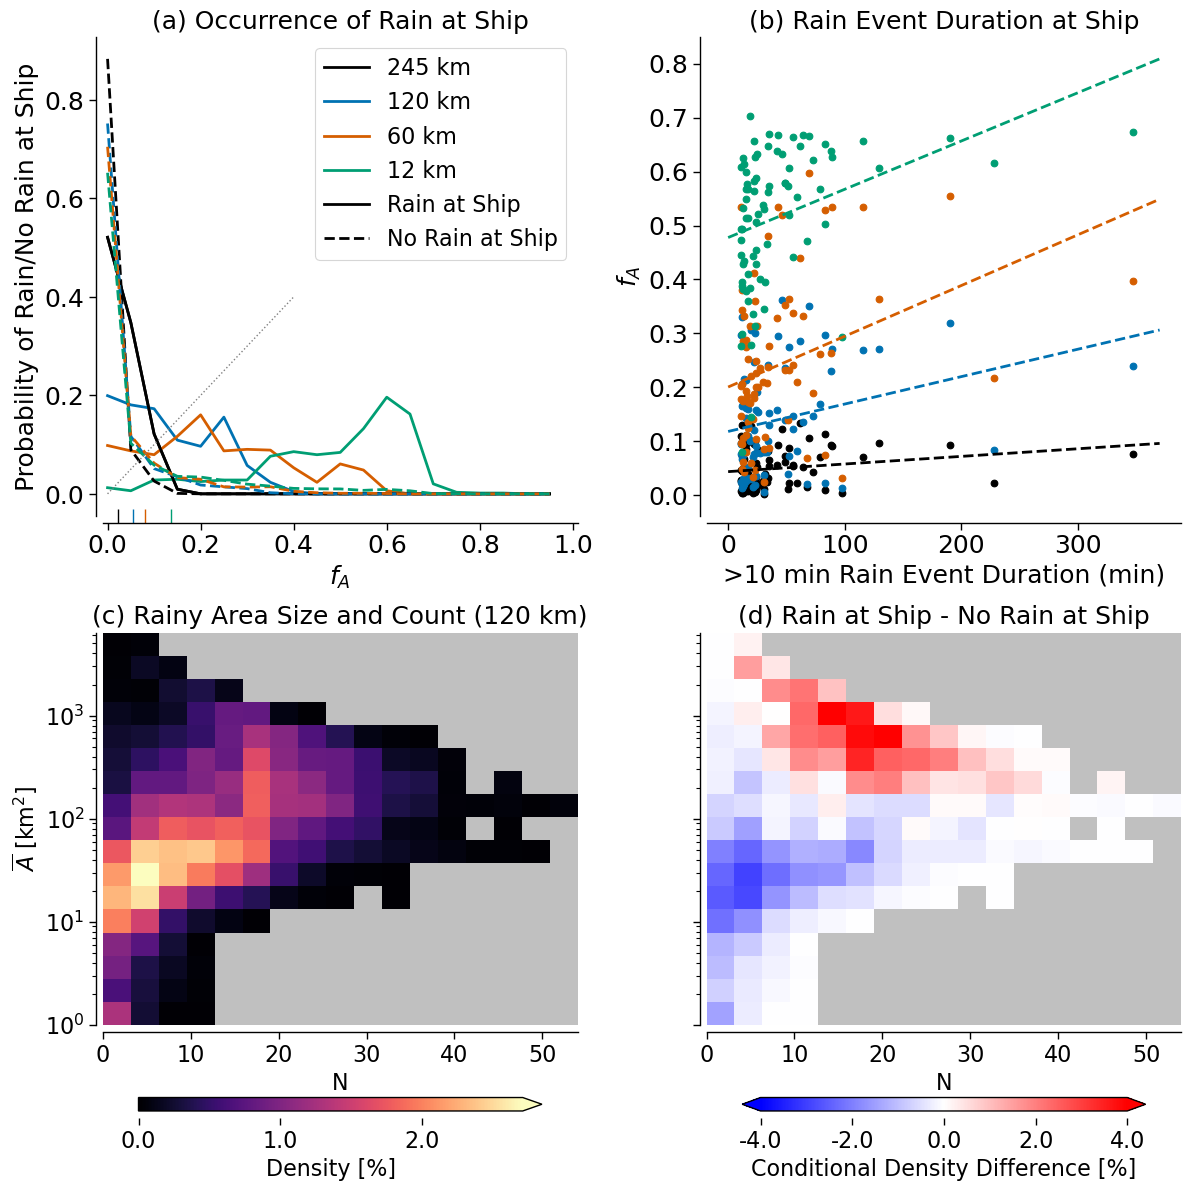

In [29]:
# Fractional area distribution when it is raining and not raining at the ship, correlation of fa with rain event duration -- gauge
# 
fig, axs = plt.subplots(2,2, figsize=(12,12))

############################ fa conditioned upon rain or not rain at ship
fabins = np.arange(0,1.05,0.05)

phist_fa245_dnz, bin_edges_dnz = np.histogram(fa245_gauge_nonzero, bins=fabins, density=True)
phist_fa120_dnz, bin_edges_dnz = np.histogram(fa120_gauge_nonzero, bins=fabins, density=True)
phist_fa60_dnz, bin_edges_dnz = np.histogram(fa60_gauge_nonzero, bins=fabins, density=True)
phist_fa12_dnz, bin_edges_dnz = np.histogram(fa12_gauge_nonzero, bins=fabins, density=True)

phist_fa245_dz, bin_edges_dz = np.histogram(fa245_gauge_zero, bins=fabins, density=True)
phist_fa120_dz, bin_edges_dz = np.histogram(fa120_gauge_zero, bins=fabins, density=True)
phist_fa60_dz, bin_edges_dz = np.histogram(fa60_gauge_zero, bins=fabins, density=True)
phist_fa12_dz, bin_edges_dz = np.histogram(fa12_gauge_zero, bins=fabins, density=True)

axs[0,0].plot(bin_edges_dnz[:-1], phist_fa245_dnz*np.diff(bin_edges_dnz), color='black',label = '245 km', linewidth=2)
axs[0,0].plot(bin_edges_dnz[:-1], phist_fa120_dnz*np.diff(bin_edges_dnz), color=cb_blue,label = '120 km', linewidth=2)
axs[0,0].plot(bin_edges_dnz[:-1], phist_fa60_dnz*np.diff(bin_edges_dnz), color=cb_red,label = '60 km', linewidth=2)
axs[0,0].plot(bin_edges_dnz[:-1], phist_fa12_dnz*np.diff(bin_edges_dnz), color=cb_green,label = '12 km', linewidth=2)

axs[0,0].plot(bin_edges_dnz[:-1], phist_fa245_dnz*np.diff(bin_edges_dnz), color='black',linewidth=2, label = 'Rain at Ship')
axs[0,0].plot(bin_edges_dz[:-1], phist_fa245_dz*np.diff(bin_edges_dz), color='black', linestyle='--', linewidth=2,label = 'No Rain at Ship')
axs[0,0].plot(bin_edges_dz[:-1], phist_fa120_dz*np.diff(bin_edges_dz), color=cb_blue, linestyle='--', linewidth=2)
axs[0,0].plot(bin_edges_dz[:-1], phist_fa60_dz*np.diff(bin_edges_dz), color=cb_red, linestyle='--', linewidth=2)
axs[0,0].plot(bin_edges_dz[:-1], phist_fa12_dz*np.diff(bin_edges_dz), color=cb_green, linestyle='--', linewidth=2)

# plot 1:1 Line
axs[0,0].plot([0,0.4], [0,0.4], color='gray', linestyle=':', linewidth=1)

# plot mean values of np.nanmean(seapol.rain245_frac) as scatters
axs[0,0].plot(np.nanmean(seapol.rain245_frac), 0, '|', color='black', markersize=10, transform=axs[0,0].get_xaxis_transform(), clip_on=False)
axs[0,0].plot(np.nanmean(seapol.rain120_frac), 0, '|', color=cb_blue, markersize=10, transform=axs[0,0].get_xaxis_transform(), clip_on=False)
axs[0,0].plot(np.nanmean(seapol.rain60_frac), 0, '|', color=cb_red, markersize=10, transform=axs[0,0].get_xaxis_transform(), clip_on=False)
axs[0,0].plot(np.nanmean(seapol.rain12_frac), 0, '|', color=cb_green, markersize=10, transform=axs[0,0].get_xaxis_transform(), clip_on=False)

# set plot attributes
axs[0,0].set_title('(a) Occurrence of Rain at Ship',fontsize=18)
axs[0,0].set_ylabel('Probability of Rain/No Rain at Ship',fontsize=18)
axs[0,0].set_xlabel('$f_A$',fontsize=18)
axs[0,0].set_xlim(-0.01,1.01)
axs[0,0].tick_params(labelsize=18)
axs[0,0].legend(fontsize=16, loc='upper right')

################################ Correlation of fa with rain event duration

axs[0,1].scatter(precip_gauge_df_10min['duration'].dt.total_seconds()/60, precip_gauge_df_10min['fa245'], color='black',label='245 km')
axs[0,1].scatter(precip_gauge_df_10min['duration'].dt.total_seconds()/60, precip_gauge_df_10min['fa120'], color=cb_blue,label='120 km')
axs[0,1].scatter(precip_gauge_df_10min['duration'].dt.total_seconds()/60, precip_gauge_df_10min['fa60'], color=cb_red,label='60 km')
axs[0,1].scatter(precip_gauge_df_10min['duration'].dt.total_seconds()/60, precip_gauge_df_10min['fa12'], color=cb_green,label='12 km')

#add regression line, ignoring nan values
valid_indices = ~np.isnan(precip_gauge_df_10min['fa60'])
z = np.polyfit((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa60'][valid_indices], 1)
p = np.poly1d(z)
axs[0,1].plot(np.arange(0,375,10), p(np.arange(0,375,10)), color=cb_red, linestyle='--', linewidth=2)

valid_indices = ~np.isnan(precip_gauge_df_10min['fa120'])
z = np.polyfit((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa120'][valid_indices], 1)
p = np.poly1d(z)
axs[0,1].plot(np.arange(0,375,10), p(np.arange(0,375,10)), color=cb_blue, linestyle='--', linewidth=2)

valid_indices = ~np.isnan(precip_gauge_df_10min['fa245'])
z = np.polyfit((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa245'][valid_indices], 1)
p = np.poly1d(z)
axs[0,1].plot(np.arange(0,375,10), p(np.arange(0,375,10)), color='black', linestyle='--', linewidth=2)

valid_indices = ~np.isnan(precip_gauge_df_10min['fa12'])
z = np.polyfit((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa12'][valid_indices], 1)
p = np.poly1d(z)
axs[0,1].plot(np.arange(0,375,10), p(np.arange(0,375,10)), color=cb_green, linestyle='--', linewidth=2)

axs[0,1].set_xlabel('>10 min Rain Event Duration (min)', fontsize=18)
axs[0,1].set_ylabel('$f_A$', fontsize=18)
axs[0,1].set_title('(b) Rain Event Duration at Ship', fontsize=18)
axs[0,1].tick_params(labelsize=18)
#axs[0,1].legend(loc='upper right',fontsize=12)

#sns.set_context('paper') 
#sns.despine(offset=5)

####################### Plot density of abar vs n

# Use mesh grid for pcolormesh. 
X, Y = np.meshgrid(xedges, yedges)

sum_all = H_all.sum() # sum all scenes to get total count for density calculation
dens_all = H_all / sum_all 
Z_left = dens_all.T

# Plot density with pcolormesh, scaling color to data range
pcm_left = axs[1,0].pcolormesh(X, Y, Z_left, cmap='magma', shading='auto')
vleft = np.nanmax(Z_left)
pcm_left.set_clim(0, float(vleft))

# Set y-axis to a log scale, label axes, and title. 
axs[1,0].set_yscale('log')
axs[1,0].set_xlabel('N', fontsize=16)
axs[1,0].set_ylabel('$\\overline{A}$ [km$^2$]', fontsize=16)
axs[1,0].set_title('(c) Rainy Area Size and Count (120 km)', fontsize=18)
axs[1,0].tick_params(axis='both', which='major', labelsize=16)

# Overlay silver for empty bins. 
if np.any(Z_left == 0):
    empty_overlay = np.where(Z_left == 0, 1.0, np.nan)
    cmap_silver = ListedColormap(['silver'])
    axs[1,0].pcolormesh(X, Y, empty_overlay, cmap=cmap_silver, shading='auto', alpha=1, zorder=2)

############### Plot density difference of abar vs. n for rain at ship - no rain at ship. 
Z_right = diff_masked.T
v = np.nanmax(np.abs(Z_right))
v = float(v) if np.isfinite(v) and v > 0 else 1.0
pcm_right = axs[1,1].pcolormesh(X, Y, Z_right, cmap='bwr', shading='auto', vmin=-.04, vmax=0.04)

# Set y-axis to a log scale, label axes, and title.
axs[1,1].set_yscale('log')
axs[1,1].set_xlabel('N', fontsize=16)
axs[1,1].set_title('(d) Rain at Ship - No Rain at Ship', fontsize=18)
axs[1,1].yaxis.set_tick_params(labelleft=False)  # shared y, hide labels on right
axs[1,1].tick_params(axis='both', which='major', labelsize=16)

# Overlay silver for empty bins. 
if np.any(Z_left == 0):
    empty_overlay = np.where(Z_left == 0, 1.0, np.nan)
    cmap_silver = ListedColormap(['silver'])
    axs[1,1].pcolormesh(X, Y, empty_overlay, cmap=cmap_silver, shading='auto', alpha=1, zorder=2)

# Add colorbar. 
pct_formatter = FuncFormatter(lambda x, pos: f"{x*100:.1f}")

# Left plot colorbar. 
cbar_left = fig.colorbar(
    pcm_left, ax=axs[1,0], orientation='horizontal',
    pad=0.15, shrink=0.85, fraction=0.03, aspect=30, anchor=(0.5, 0.0), extend='max'
)
cbar_left.ax.xaxis.set_ticks_position('bottom')
cbar_left.set_label(r'Density [%]', fontsize=16)
cbar_left.ax.xaxis.set_major_formatter(pct_formatter)
cbar_left.ax.xaxis.set_tick_params(labelsize=16)

# Right plot colorbar.
cbar_right = fig.colorbar(
    pcm_right, ax=axs[1,1], orientation='horizontal',
    pad=0.15, shrink=0.85, fraction=0.03, aspect=30, anchor=(0.5, 0.0), extend='both'
)
cbar_right.ax.xaxis.set_ticks_position('bottom')
cbar_right.ax.xaxis.set_major_formatter(pct_formatter)
cbar_right.set_ticks(np.linspace(-.04, 0.04, 5))
cbar_right.set_label(
    r'Conditional Density Difference [%]',
    fontsize=16
)
cbar_right.ax.xaxis.set_tick_params(labelsize=16)

# Ensure limits are correct. 
axs[1,0].set_xlim(xedges[0], xedges[-1])
axs[1,0].set_xlim(xedges[0], xedges[-1])
axs[1,1].set_ylim(yedges[0], yedges[-1])
axs[1,1].set_ylim(yedges[0], yedges[-1])

sns.set_context('paper') 
sns.despine(offset=5)
sns.despine(ax=cbar_left.ax, left=True, bottom=True, right=True, top=True)
sns.despine(ax=cbar_right.ax, left=True, bottom=True, right=True, top=True)
plt.tight_layout()  # Adjust subplots to fit into figure area.

plt.savefig('./figures/Fig_precip_stats.pdf')

## Statistics

In [21]:
# How often is the fractional area greater than average when the ship observes no rain?
fa245_gauge_zero_gtmean = fa245_gauge_zero.where(fa245_gauge_zero > np.nanmean(seapol.rain245_frac))
fa245_gauge_zero_gtmean_count = np.count_nonzero(~np.isnan(fa245_gauge_zero_gtmean))
fa245_gauge_zero_count = np.count_nonzero(~np.isnan(fa245_gauge_zero))
print(f"Fraction of times FA245 is greater than mean when ship gauge observes no rain: {fa245_gauge_zero_gtmean_count/fa245_gauge_zero_count:.2f}")

fa120_gauge_zero_gtmean = fa120_gauge_zero.where(fa120_gauge_zero > np.nanmean(seapol.rain120_frac))
fa120_gauge_zero_gtmean_count = np.count_nonzero(~np.isnan(fa120_gauge_zero_gtmean))
fa120_gauge_zero_count = np.count_nonzero(~np.isnan(fa120_gauge_zero))
print(f"Fraction of times FA120 is greater than mean when ship gauge observes no rain: {fa120_gauge_zero_gtmean_count/fa120_gauge_zero_count:.2f}")

fa60_gauge_zero_gtmean = fa60_gauge_zero.where(fa60_gauge_zero > np.nanmean(seapol.rain60_frac))
fa60_gauge_zero_gtmean_count = np.count_nonzero(~np.isnan(fa60_gauge_zero_gtmean))
fa60_gauge_zero_count = np.count_nonzero(~np.isnan(fa60_gauge_zero))
print(f"Fraction of times FA60 is greater than mean when ship gauge observes no rain: {fa60_gauge_zero_gtmean_count/fa60_gauge_zero_count:.2f}")

fa12_gauge_zero_gtmean = fa12_gauge_zero.where(fa12_gauge_zero > np.nanmean(seapol.rain12_frac))
fa12_gauge_zero_gtmean_count = np.count_nonzero(~np.isnan(fa12_gauge_zero_gtmean))
fa12_gauge_zero_count = np.count_nonzero(~np.isnan(fa12_gauge_zero))
print(f"Fraction of times FA12 is greater than mean when ship gauge observes no rain: {fa12_gauge_zero_gtmean_count/fa12_gauge_zero_count:.2f}")

Fraction of times FA245 is greater than mean when ship gauge observes no rain: 0.25
Fraction of times FA120 is greater than mean when ship gauge observes no rain: 0.23
Fraction of times FA60 is greater than mean when ship gauge observes no rain: 0.21
Fraction of times FA12 is greater than mean when ship gauge observes no rain: 0.20


In [22]:
#When the fractional area is above its 95th percentile, how often is it raining at the ship?
which_prctile = 95
fa245_i95 = np.where(seapol.rain245_frac >= np.nanpercentile(seapol.rain245_frac, [which_prctile]))
precip_freq_gauge_i95 = precip_freq_gauge[fa245_i95]
print(f"Fraction of time 10-min precip freq is greater than {pfreq_threshold} when FA245 is above its 95th percentile: {np.count_nonzero(precip_freq_gauge_i95 > pfreq_threshold)/precip_freq_gauge_i95.size:.2f}")

fa120_i95 = np.where(seapol.rain120_frac >= np.nanpercentile(seapol.rain120_frac, [which_prctile]))
precip_freq_gauge_i95 = precip_freq_gauge[fa120_i95]
print(f"Fraction of time 10-min precip freq is greater than {pfreq_threshold} when FA120 is above its 95th percentile: {np.count_nonzero(precip_freq_gauge_i95 > pfreq_threshold)/precip_freq_gauge_i95.size:.2f}")

fa60_i95 = np.where(seapol.rain60_frac >= np.nanpercentile(seapol.rain60_frac, [which_prctile]))
precip_freq_gauge_i95 = precip_freq_gauge[fa60_i95]
print(f"Fraction of time 10-min precip freq is greater than {pfreq_threshold} when FA60 is above its 95th percentile: {np.count_nonzero(precip_freq_gauge_i95 > pfreq_threshold)/precip_freq_gauge_i95.size:.2f}")

fa12_i95 = np.where(seapol.rain12_frac >= np.nanpercentile(seapol.rain12_frac, [which_prctile]))
precip_freq_gauge_i95 = precip_freq_gauge[fa12_i95]
print(f"Fraction of time 10-min precip freq is greater than {pfreq_threshold} when FA12 is above its 95th percentile: {np.count_nonzero(precip_freq_gauge_i95 > pfreq_threshold)/precip_freq_gauge_i95.size:.2f}")

Fraction of time 10-min precip freq is greater than 0 when FA245 is above its 95th percentile: 0.42
Fraction of time 10-min precip freq is greater than 0 when FA120 is above its 95th percentile: 0.54
Fraction of time 10-min precip freq is greater than 0 when FA60 is above its 95th percentile: 0.63
Fraction of time 10-min precip freq is greater than 0 when FA12 is above its 95th percentile: 0.77


## Correlations with duration

In [23]:
# calculate correlation coefficient between duration and fa
valid_indices = ~np.isnan(precip_gauge_df_10min['fa245'])
corr_coef, p_value = pearsonr((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa245'][valid_indices])
print(f"Correlation coefficient between duration of rain events > 10 min and FA245: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min['fa120'])
corr_coef, p_value = pearsonr((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa120'][valid_indices])
print(f"Correlation coefficient between duration of rain events > 10 min and FA120: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min['fa60'])
corr_coef, p_value = pearsonr((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa60'][valid_indices])
print(f"Correlation coefficient between duration of rain events > 10 min and FA60: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min['fa12'])
corr_coef, p_value = pearsonr((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa12'][valid_indices])
print(f"Correlation coefficient between duration of rain events > 10 min and FA12: {corr_coef}", f"p-value: {p_value}")


Correlation coefficient between duration of rain events > 10 min and FA245: 0.19881043769533832 p-value: 0.07707394814579041
Correlation coefficient between duration of rain events > 10 min and FA120: 0.26649470579623263 p-value: 0.016872647505797853
Correlation coefficient between duration of rain events > 10 min and FA60: 0.3315134037077046 p-value: 0.00266528404965244
Correlation coefficient between duration of rain events > 10 min and FA12: 0.35442107062696265 p-value: 0.0012573732225708346


In [24]:
# calculate spearman rank correlation coefficient between duration and fa
valid_indices = ~np.isnan(precip_gauge_df_10min['fa245'])
corr_coef, p_value = spearmanr((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa245'][valid_indices])
print(f"Spearman rank correlation coefficient between duration of rain events > 10 min and FA245: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min['fa120'])
corr_coef, p_value = spearmanr((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa120'][valid_indices])
print(f"Spearman rank correlation coefficient between duration of rain events > 10 min and FA120: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min['fa60'])
corr_coef, p_value = spearmanr((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa60'][valid_indices])
print(f"Spearman rank correlation coefficient between duration of rain events > 10 min and FA60: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min['fa12'])
corr_coef, p_value = spearmanr((precip_gauge_df_10min['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min['fa12'][valid_indices])
print(f"Spearman rank correlation coefficient between duration of rain events > 10 min and FA12: {corr_coef}", f"p-value: {p_value}")

Spearman rank correlation coefficient between duration of rain events > 10 min and FA245: 0.23801709829790788 p-value: 0.03349986291465588
Spearman rank correlation coefficient between duration of rain events > 10 min and FA120: 0.2460975999351219 p-value: 0.027772676272948348
Spearman rank correlation coefficient between duration of rain events > 10 min and FA60: 0.3464295179414585 p-value: 0.0016445866356303925
Spearman rank correlation coefficient between duration of rain events > 10 min and FA12: 0.4974610129836096 p-value: 2.6731549606847704e-06


In [25]:
# calculate correlation coefficient between duration and fa
valid_indices = ~np.isnan(precip_gauge_df_10min_nolong['fa245'])
corr_coef, p_value = pearsonr((precip_gauge_df_10min_nolong['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min_nolong['fa245'][valid_indices])
print(f"Correlation coefficient between duration of rain events > 10 min, < 60 min and FA245: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min_nolong['fa120'])
corr_coef, p_value = pearsonr((precip_gauge_df_10min_nolong['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min_nolong['fa120'][valid_indices])
print(f"Correlation coefficient between duration of rain events > 10 min, < 60 min and FA120: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min_nolong['fa60'])
corr_coef, p_value = pearsonr((precip_gauge_df_10min_nolong['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min_nolong['fa60'][valid_indices])
print(f"Correlation coefficient between duration of rain events > 10 min, < 60 min and FA60: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min_nolong['fa12'])
corr_coef, p_value = pearsonr((precip_gauge_df_10min_nolong['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min_nolong['fa12'][valid_indices])
print(f"Correlation coefficient between duration of rain events > 10 min, < 60 min and FA12: {corr_coef}", f"p-value: {p_value}")


Correlation coefficient between duration of rain events > 10 min, < 60 min and FA245: 0.12614299417825067 p-value: 0.3205983345902131
Correlation coefficient between duration of rain events > 10 min, < 60 min and FA120: 0.15589375287265778 p-value: 0.21865710289419096
Correlation coefficient between duration of rain events > 10 min, < 60 min and FA60: 0.28479964039874817 p-value: 0.022551304545564387
Correlation coefficient between duration of rain events > 10 min, < 60 min and FA12: 0.3669025556666167 p-value: 0.002862566917520155


In [26]:
# calculate spearman rank correlation coefficient between duration and fa
valid_indices = ~np.isnan(precip_gauge_df_10min_nolong['fa245'])
corr_coef, p_value = spearmanr((precip_gauge_df_10min_nolong['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min_nolong['fa245'][valid_indices])
print(f"Spearman rank correlation coefficient between duration of rain events > 10 min, < 60 min and FA245: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min_nolong['fa120'])
corr_coef, p_value = spearmanr((precip_gauge_df_10min_nolong['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min_nolong['fa120'][valid_indices])
print(f"Spearman rank correlation coefficient between duration of rain events > 10 min, < 60 min and FA120: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min_nolong['fa60'])
corr_coef, p_value = spearmanr((precip_gauge_df_10min_nolong['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min_nolong['fa60'][valid_indices])
print(f"Spearman rank correlation coefficient between duration of rain events > 10 min, < 60 min and FA60: {corr_coef}", f"p-value: {p_value}")

valid_indices = ~np.isnan(precip_gauge_df_10min_nolong['fa12'])
corr_coef, p_value = spearmanr((precip_gauge_df_10min_nolong['duration'].dt.total_seconds()/60)[valid_indices], precip_gauge_df_10min_nolong['fa12'][valid_indices])
print(f"Spearman rank correlation coefficient between duration of rain events > 10 min, < 60 min and FA12: {corr_coef}", f"p-value: {p_value}")

Spearman rank correlation coefficient between duration of rain events > 10 min, < 60 min and FA245: 0.13535050771907572 p-value: 0.2862521813620293
Spearman rank correlation coefficient between duration of rain events > 10 min, < 60 min and FA120: 0.13198107086307162 p-value: 0.2985282124486445
Spearman rank correlation coefficient between duration of rain events > 10 min, < 60 min and FA60: 0.2596300086255666 p-value: 0.038286303591479054
Spearman rank correlation coefficient between duration of rain events > 10 min, < 60 min and FA12: 0.3861099580910805 p-value: 0.0016261855226699326
